In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24140139"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))

学生： 24140139
专题： A
输出： output\day06_visualization


In [4]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")

,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均优惠券数,平均返现,平均距上次下单天数,用户占比
0,新用户,508,272,0.54,1.89,0.96,142.44,2.88,0.09
1,0-6个月,1642,425,0.26,2.68,1.74,164.87,4.05,0.29
2,7-12个月,1584,156,0.10,2.75,1.60,163.31,4.38,0.28
3,13-24个月,1467,95,0.06,3.70,2.02,204.92,5.32,0.26
4,24个月以上,429,0,0.00,3.55,1.94,222.34,5.26,0.08


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,平均满意度,样本提示,投诉状态
0,新用户,1,194,139,0.72,2.12,2.94,可观察,有投诉
1,0-6个月,1,465,236,0.51,2.87,3.03,可观察,有投诉
2,新用户,0,314,133,0.42,1.75,3.32,可观察,无投诉
3,7-12个月,1,406,81,0.20,2.67,3.02,可观察,有投诉
4,0-6个月,0,1177,189,0.16,2.61,3.11,可观察,无投诉


检查点1A通过：输入文件有效


In [6]:
# TODO: 填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同商品类别的用户数量与流失率有何差异？",
    "behavior_scatter": "用户订单数与返现金额之间是否存在关系？流失用户在分布上有何特点？",
    "ordered_line": "不同会员时长阶段（新用户→长期用户）的流失率如何变化？",
    "composition_chart": "用户偏好的支付方式整体构成是怎样的？",
}

chart_reasons = {
    "category_bar": "柱状图适合比较多个类别的用户数和流失率，能直观看出哪些类别表现好或差。",
    "behavior_scatter": "散点图适合展示两个数值变量的关系，用颜色区分流失状态可以观察两类用户的分布差异。",
    "ordered_line": "折线图适合展示有序阶段（如会员时长）的变化趋势，能清晰看出流失率随会员时长的变化规律。",
    "composition_chart": "支付方式类别为5种，适合使用饼图展示整体构成，便于看出哪种支付方式最受欢迎。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过，业务问题和选择理由已填写")

检查点1B通过，业务问题和选择理由已填写


In [8]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "PreferedOrderCat"

category_summary = (
    df.groupby(category_field, observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          流失率=("Churn", "mean"),
          平均订单数=("OrderCount", "mean")
      )
      .reset_index()
      .sort_values("用户数", ascending=False)
)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,PreferedOrderCat,用户数,流失率,平均订单数
3,Mobile Phone,2080,0.27,2.18
2,Laptop & Accessory,2050,0.10,2.77
0,Fashion,826,0.15,3.87
1,Grocery,410,0.05,4.60
4,Others,264,0.08,5.25


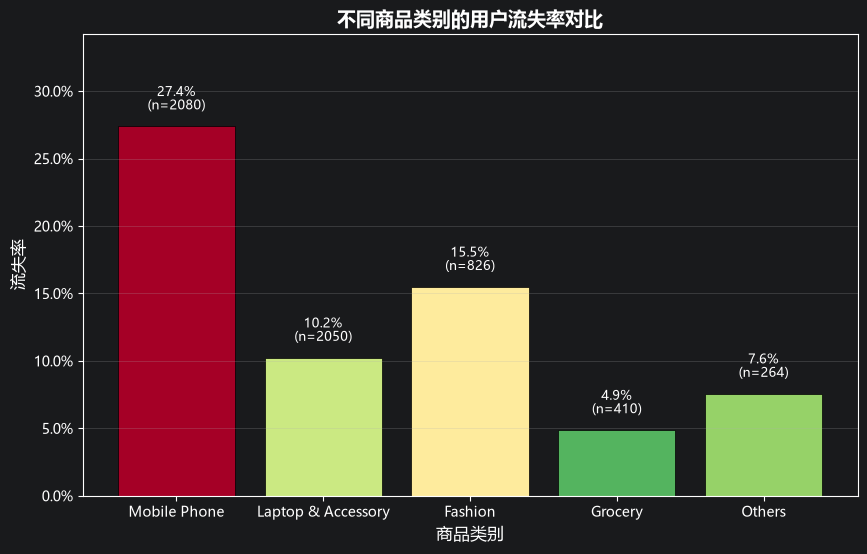

已输出： output\day06_visualization\01_category_bar.png


In [10]:
# TODO: 绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 绘制柱状图
bars = ax_bar.bar(
    category_summary["PreferedOrderCat"],
    category_summary["流失率"],
    color=plt.cm.RdYlGn_r(category_summary["流失率"] / category_summary["流失率"].max()),
    edgecolor="black",
    linewidth=0.5,
)

# 在柱子上标注流失率
for bar, rate, count in zip(bars, category_summary["流失率"], category_summary["用户数"]):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{rate:.1%}\n(n={count})",
                ha="center", va="bottom", fontsize=9)

ax_bar.set_xlabel("商品类别", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.set_title("不同商品类别的用户流失率对比", fontsize=14, fontweight="bold")
ax_bar.set_ylim(0, max(category_summary["流失率"]) * 1.25)
ax_bar.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_bar.grid(axis="y", alpha=0.3)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

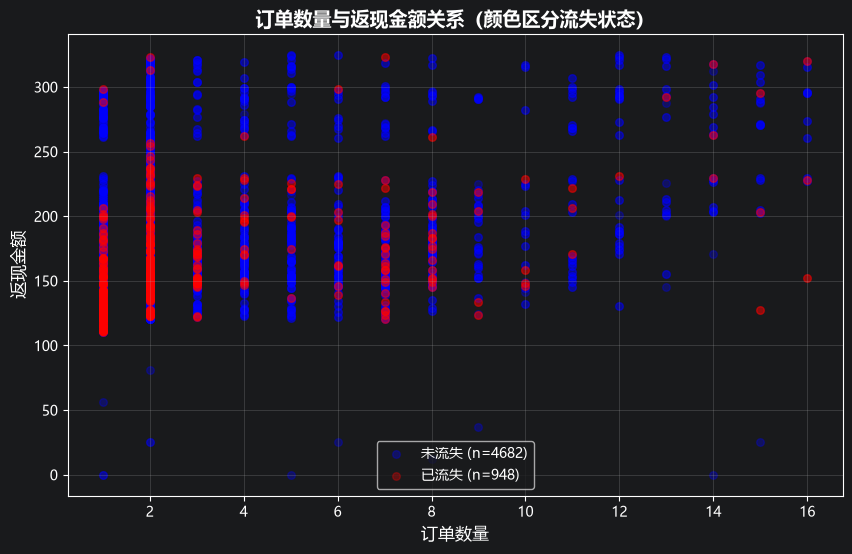

已输出： output\day06_visualization\02_behavior_scatter.png


In [11]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn分组绘制散点图
for churn_val, color, label in [(0, "blue", "未流失"), (1, "red", "已流失")]:
    subset = df[df["Churn"] == churn_val]
    ax_scatter.scatter(
        subset[x_field],
        subset[y_field],
        alpha=0.3,
        s=30,
        color=color,
        label=f"{label} (n={len(subset)})"
    )

ax_scatter.set_xlabel("订单数量", fontsize=12)
ax_scatter.set_ylabel("返现金额", fontsize=12)
ax_scatter.set_title("订单数量与返现金额关系（颜色区分流失状态）", fontsize=14, fontweight="bold")
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

In [12]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"

ordered_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          流失人数=("Churn", "sum"),
          流失率=("Churn", "mean")
      )
      .reset_index()
)

# 按顺序排列
ordered_summary["TenureGroup"] = pd.Categorical(
    ordered_summary["TenureGroup"],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values("TenureGroup")

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失人数,流失率
4,新用户,508,272,0.54
0,0-6个月,1642,425,0.26
3,7-12个月,1584,156,0.10
1,13-24个月,1467,95,0.06
2,24个月以上,429,0,0.00


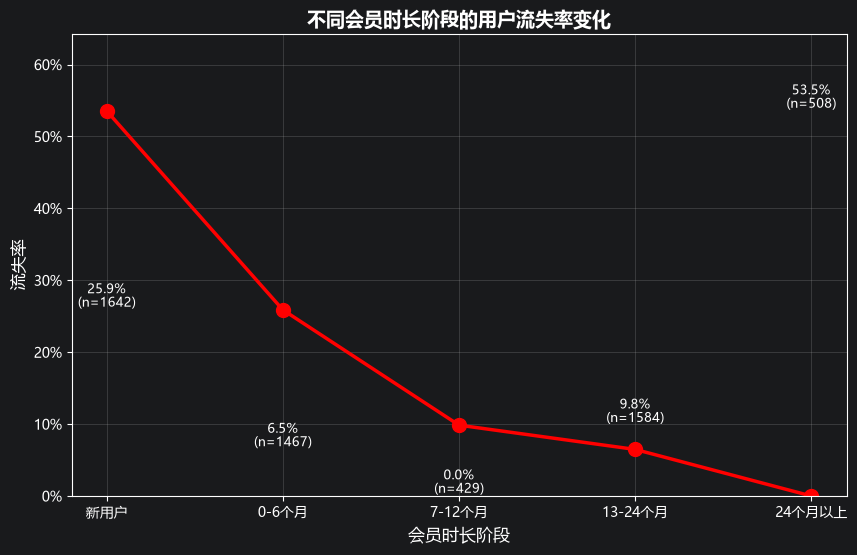

已输出： output\day06_visualization\03_ordered_line.png


In [13]:
# TODO：绘制折线图
fig_line, ax_line = plt.subplots(figsize=(10, 6))

ax_line.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["流失率"],
    marker="o",
    linewidth=2.5,
    markersize=10,
    color="red",
    label="流失率"
)

for i, row in ordered_summary.iterrows():
    ax_line.annotate(
        f"{row['流失率']:.1%}\n(n={row['用户数']})",
        (i, row["流失率"]),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax_line.set_xlabel("会员时长阶段", fontsize=12)
ax_line.set_ylabel("流失率", fontsize=12)
ax_line.set_title("不同会员时长阶段的用户流失率变化", fontsize=14, fontweight="bold")
ax_line.set_ylim(0, max(ordered_summary["流失率"]) * 1.2)
ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_line.grid(alpha=0.3)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

In [14]:
# TODO：选择构成字段并准备汇总表
composition_field = "PreferredPaymentMode"

composition_summary = (
    df[composition_field]
      .value_counts()
      .reset_index()
)
composition_summary.columns = [composition_field, "用户数"]
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)

,PreferredPaymentMode,用户数,占比
0,Debit Card,2314,0.41
1,Credit Card,1774,0.32
2,E wallet,614,0.11
3,Cash on Delivery,514,0.09
4,UPI,414,0.07


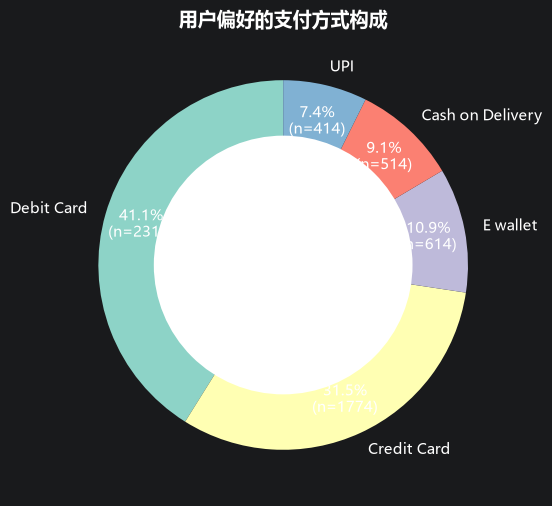

已输出： output\day06_visualization\04_composition_chart.png


In [15]:
# TODO：类别不超过5个时绘制环形图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

colors = plt.cm.Set3(range(len(composition_summary)))

wedges, texts, autotexts = ax_composition.pie(
    composition_summary["用户数"],
    labels=composition_summary[composition_field],
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(pct/100 * composition_summary['用户数'].sum())})",
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={"fontsize": 11}
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax_composition.add_artist(centre_circle)

ax_composition.set_title("用户偏好的支付方式构成", fontsize=14, fontweight="bold")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

In [16]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")

检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


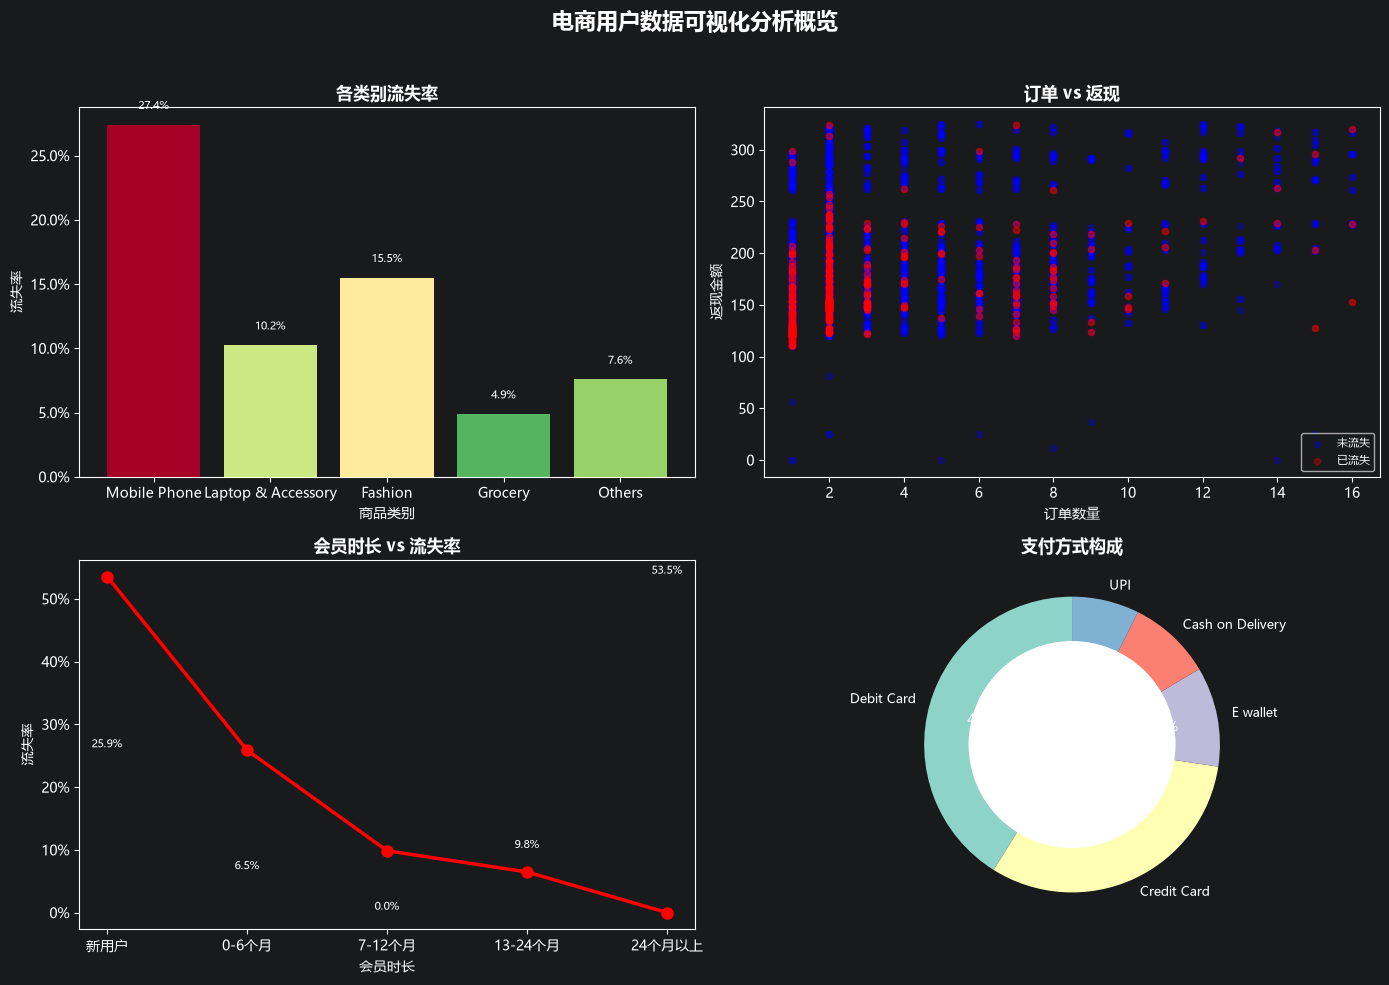

已输出： output\day06_visualization\day06_visualization_summary.png


In [17]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# 子图1：类别流失率柱状图
ax1 = axes[0, 0]
bars = ax1.bar(
    category_summary["PreferedOrderCat"],
    category_summary["流失率"],
    color=plt.cm.RdYlGn_r(category_summary["流失率"] / category_summary["流失率"].max())
)
for bar, rate in zip(bars, category_summary["流失率"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{rate:.1%}", ha="center", va="bottom", fontsize=8)
ax1.set_xlabel("商品类别", fontsize=10)
ax1.set_ylabel("流失率", fontsize=10)
ax1.set_title("各类别流失率", fontsize=12, fontweight="bold")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))

# 子图2：散点图
ax2 = axes[0, 1]
for churn_val, color, label in [(0, "blue", "未流失"), (1, "red", "已流失")]:
    subset = df[df["Churn"] == churn_val]
    ax2.scatter(subset["OrderCount"], subset["CashbackAmount"],
                alpha=0.3, s=20, color=color, label=label)
ax2.set_xlabel("订单数量", fontsize=10)
ax2.set_ylabel("返现金额", fontsize=10)
ax2.set_title("订单 vs 返现", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8)

# 子图3：折线图
ax3 = axes[1, 0]
ax3.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"],
         marker="o", linewidth=2.5, markersize=8, color="red")
for i, row in ordered_summary.iterrows():
    ax3.annotate(f"{row['流失率']:.1%}", (i, row["流失率"]),
                 ha="center", va="bottom", fontsize=8)
ax3.set_xlabel("会员时长", fontsize=10)
ax3.set_ylabel("流失率", fontsize=10)
ax3.set_title("会员时长 vs 流失率", fontsize=12, fontweight="bold")
ax3.yaxis.set_major_formatter(PercentFormatter(1.0))

# 子图4：构成图
ax4 = axes[1, 1]
colors = plt.cm.Set3(range(len(composition_summary)))
wedges, texts, autotexts = ax4.pie(
    composition_summary["用户数"],
    labels=composition_summary["PreferredPaymentMode"],
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    colors=colors,
    textprops={"fontsize": 9}
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax4.add_artist(centre_circle)
ax4.set_title("支付方式构成", fontsize=12, fontweight="bold")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

In [18]:
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同商品类别的用户数量与流失率有何差异？",
        "chart_type": "bar",
        "key_finding": "手机类目用户最多（2080人），流失率最高（27%）；杂货类目流失率最低（5%）",
        "limitation": "不能说明各类别流失率差异的根本原因"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "用户订单数与返现金额之间是否存在关系？",
        "chart_type": "scatter",
        "key_finding": "流失用户订单数较少（均值2.81），返现较低（160.37元）；未流失用户订单较多（2.99），返现较高（180.64元）",
        "limitation": "相关关系不等于因果关系，返现金额不等于消费金额"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "不同会员时长阶段的用户流失率如何变化？",
        "chart_type": "line",
        "key_finding": "新用户流失率最高（54%），随着会员时长增加，流失率逐步下降至0%",
        "limitation": "有序阶段比较，不是历史时间趋势"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "用户偏好的支付方式整体构成是怎样的？",
        "chart_type": "pie",
        "key_finding": "借记卡最受欢迎（41.1%），信用卡次之（31.5%），现金支付最少（9.1%）",
        "limitation": "反映的是支付方式偏好，不是实际交易金额"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体概览",
        "chart_type": "dashboard",
        "key_finding": "手机类目流失最高，新用户流失最高，借记卡最受欢迎",
        "limitation": "综合图仅用于概览，详细分析需查看独立图表"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同商品类别的用户数量与流失率有何差异？,bar,手机类目用户最多（2080人），流失率最高（27%）；杂货类目流失率最低（5%）,不能说明各类别流失率差异的根本原因
1,02,02_behavior_scatter.png,用户订单数与返现金额之间是否存在关系？,scatter,流失用户订单数较少（均值2.81），返现较低（160.37元）；未流失用户订单较多（2.99...,相关关系不等于因果关系，返现金额不等于消费金额
2,03,03_ordered_line.png,不同会员时长阶段的用户流失率如何变化？,line,新用户流失率最高（54%），随着会员时长增加，流失率逐步下降至0%,有序阶段比较，不是历史时间趋势
3,04,04_composition_chart.png,用户偏好的支付方式整体构成是怎样的？,pie,借记卡最受欢迎（41.1%），信用卡次之（31.5%），现金支付最少（9.1%）,反映的是支付方式偏好，不是实际交易金额
4,05,day06_visualization_summary.png,整体概览,dashboard,手机类目流失最高，新用户流失最高，借记卡最受欢迎,综合图仅用于概览，详细分析需查看独立图表


In [19]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")

检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
